In [1]:
!pip install torchtt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.6/524.6 kB 7.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached ninja-1.11.1.4-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

TT cores [tensor([[[ 0.9995, -0.0322],
         [ 0.0322,  0.9995]]], dtype=torch.float64), tensor([[[ 7.0747e-01,  3.3307e-05],
         [ 7.0601e-01, -3.2141e-02]],

        [[ 2.2704e-02,  9.9948e-01],
         [-2.2751e-02,  1.0357e-03]]], dtype=torch.float64), tensor([[[ 7.0784e-01,  9.3481e-05],
         [ 7.0492e-01, -4.5291e-02]],

        [[ 3.1960e-02,  9.9897e-01],
         [-3.2092e-02,  2.0619e-03]]], dtype=torch.float64), tensor([[[-7.0856e-01,  2.6039e-04],
         [-7.0278e-01, -6.3596e-02]],

        [[-4.4785e-02,  9.9797e-01],
         [ 4.5153e-02,  4.0860e-03]]], dtype=torch.float64), tensor([[[-7.0997e-01,  7.1468e-04],
         [-6.9862e-01, -8.8692e-02]],

        [[ 6.2209e-02, -9.9603e-01],
         [-6.3220e-02, -8.0259e-03]]], dtype=torch.float64), tensor([[[ 4.0941],
         [ 3.9682]],

        [[-0.4883],
         [ 0.5038]]], dtype=torch.float64)]
Mode size  [2, 2, 2, 2, 2, 2]
TT rank  [1, 2, np.int64(2), np.int64(2), np.int64(2), 2, 1]

--- Time Step 

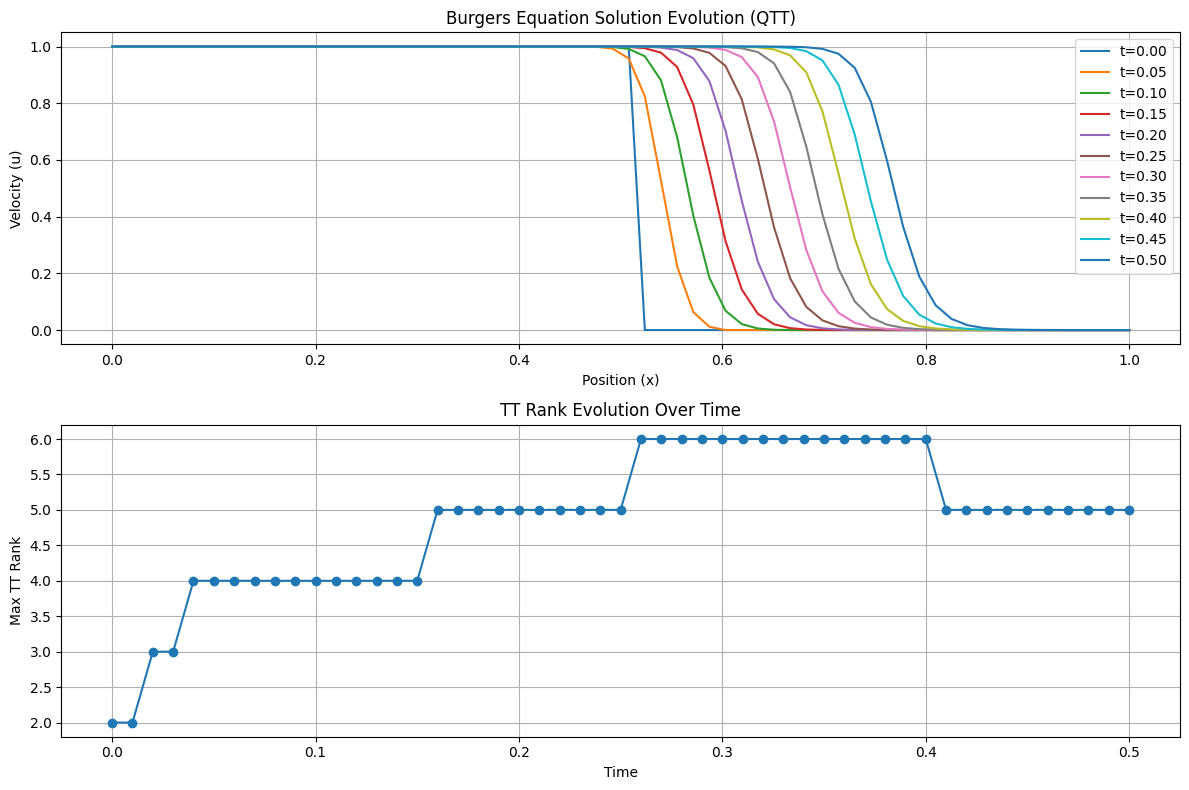

Animation saved as 'burgers_solution_evolution.gif'


In [6]:
import datetime
import numpy as np
import matplotlib.pyplot as plt
import torch as tn
import torchtt as tntt
from torchtt._fast_mult import *
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ======================
# PARAMETERS SETUP
# ======================
a = 0                  # beginning of interval
b = 1                  # end of interval
c = 6                  # number of cores in QTT
Re = 100             # Reynolds Number
dt = 0.01              # time increment
dx = (b-a)/(2**c)      # grid size
dx2 = dx**2
n = 2**c               # dimension of matrix operator
u_L = 1.0              # left BC
u_R = 0.0              # right BC
num_steps = 50         # total time steps

# ======================
# INITIAL CONDITION
# ======================
u = np.zeros(2**c)
for i in range(int((2**c)/2)+1):
    u[i] = 1

# Reshape to tensor and convert to TT format
u_r = np.reshape(u, (2,)*c)
u_tt = tntt.TT(u_r)

# Print TT properties
print('TT cores', u_tt.cores)
print('Mode size ', u_tt.N)
print('TT rank ', u_tt.R)

# ======================
# OPERATOR CREATION
# ======================
def create_first_derivative_matrix(n, dx):
    matrix = np.zeros((n, n))
    # First row (forward difference)
    matrix[0,0] = -3/(2*dx)
    matrix[0,1] = 4/(2*dx)
    matrix[0,2] = -1/(2*dx)
    # Last row (backward difference)
    matrix[n-1, n-1] = 3/(2*dx)
    matrix[n-1, n-2] = -4/(2*dx)
    matrix[n-1, n-3] = 1/(2*dx)
    # Interior points (central difference)
    for i in range(1, n-1):
        matrix[i, i-1] = -1/(2*dx)
        matrix[i, i+1] = 1/(2*dx)
    return matrix

def create_second_derivative_matrix(n, dx):
    dx2 = dx**2
    matrix = np.zeros((n, n))
    # Main diagonal
    np.fill_diagonal(matrix, -2/dx2)
    # Off-diagonals
    np.fill_diagonal(matrix[:-1,1:], 1/dx2)
    np.fill_diagonal(matrix[1:,:-1], 1/dx2)
    return matrix

# Create operators
D1 = create_first_derivative_matrix(n, dx)
D2 = create_second_derivative_matrix(n, dx)

# Convert to QTT format
D1_flat = D1.flatten()
D1_tn = tn.from_numpy(D1_flat)
D1_reshaped = tn.reshape(D1_tn, [2]*(2*c))
D1_tt = tntt.TT(D1_reshaped, eps=1e-12, shape=[(2,2)]*c)

D2_flat = D2.flatten()
D2_tn = tn.from_numpy(D2_flat)
D2_reshaped = tn.reshape(D2_tn, [2]*(2*c))
D2_tt = tntt.TT(D2_reshaped, eps=1e-12, shape=[(2,2)]*c)

# ======================
# TIME-STEPPING LOOP
# ======================
x = np.linspace(a, b, n)
solutions = [u.copy()]  # store initial solution
tt_rank_evolution = [u_tt.R]  # track rank evolution

for step in range(num_steps):
    print(f"\n--- Time Step {step+1}/{num_steps} ---")
    print(f"Current time: {(step+1)*dt:.2f}")

    # Compute derivatives in QTT format
    du_tt = D1_tt @ u_tt
    du2_tt = D2_tt @ u_tt

    # Compute terms
    diffusion_term = (1/Re) * du2_tt
    convection_term = fast_hadammard(u_tt, du_tt, eps=1e-12)

    # Combine and update
    RHS = diffusion_term - convection_term  # Note: minus sign for convection
    u_tt_new = u_tt + dt * RHS
    u_tt = u_tt_new.round(eps=1e-12, rmax=100)

    # Convert to full array for BC enforcement
    u_full = u_tt.numpy().reshape(-1)

    # Enforce boundary conditions
    u_full[0] = u_L
    u_full[-1] = u_R

    # Update QTT with enforced BCs
    u_tt = tntt.TT(tn.tensor(u_full.reshape((2,)*c)))

    # Store solution and TT rank
    solutions.append(u_full.copy())
    tt_rank_evolution.append(u_tt.R)

    print(f"TT rank: {u_tt.R}")
    print(f"Min/Max velocity: {np.min(u_full):.4f}/{np.max(u_full):.4f}")

# ======================
# VISUALIZATION
# ======================
# Plot solution evolution
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
for i, sol in enumerate(solutions):
    if i % 5 == 0:  # Plot every 5th step
        plt.plot(x, sol, label=f"t={i*dt:.2f}")
plt.title("Burgers Equation Solution Evolution (QTT)")
plt.xlabel("Position (x)")
plt.ylabel("Velocity (u)")
plt.legend()
plt.grid(True)

# Plot rank evolution
plt.subplot(2, 1, 2)
plt.plot([i*dt for i in range(len(tt_rank_evolution))], [max(r) for r in tt_rank_evolution], 'o-')
plt.title("TT Rank Evolution Over Time")
plt.xlabel("Time")
plt.ylabel("Max TT Rank")
plt.grid(True)
plt.tight_layout()
plt.savefig("burgers_solution_and_rank_evolution.png")
plt.show()

# Create animation
fig, ax = plt.subplots(figsize=(10, 6))
line, = ax.plot(x, solutions[0])
ax.set_ylim(min(u_R, u_L)-0.1, max(u_R, u_L)+0.1)
ax.set_xlabel("Position (x)")
ax.set_ylabel("Velocity (u)")
ax.set_title(f"Burgers Equation Solution (t=0.00)")
ax.grid(True)
time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)

def update(frame):
    line.set_ydata(solutions[frame])
    time_text.set_text(f"t = {frame*dt:.2f}")
    ax.set_title(f"Burgers Equation Solution (QTT, Re={Re})")
    return line, time_text

ani = FuncAnimation(fig, update, frames=len(solutions), interval=100, blit=True)
plt.close()

# Save animation
ani.save("burgers_solution_evolution.gif", writer="pillow", fps=10)
print("Animation saved as 'burgers_solution_evolution.gif'")

# Display in notebook
HTML(ani.to_jshtml())